In [25]:
import numpy as np
total_gpu = 32
num_machines = total_gpu // 8
gpu_config = np.array([1,1,0,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0])
per_node_counts = [int(sum(gpu_config[i*8:(i+1)*8])) for i in range(num_machines)]
total_active_gpus = int(sum(per_node_counts))
total_active_gpus,per_node_counts

(15, [3, 4, 4, 4])

# 效果图

## Bandwidth Surrogate Model Accuracy

R-squared (R²): 0.9627
Error Mean: 0.4020, Error Std: 3.7190


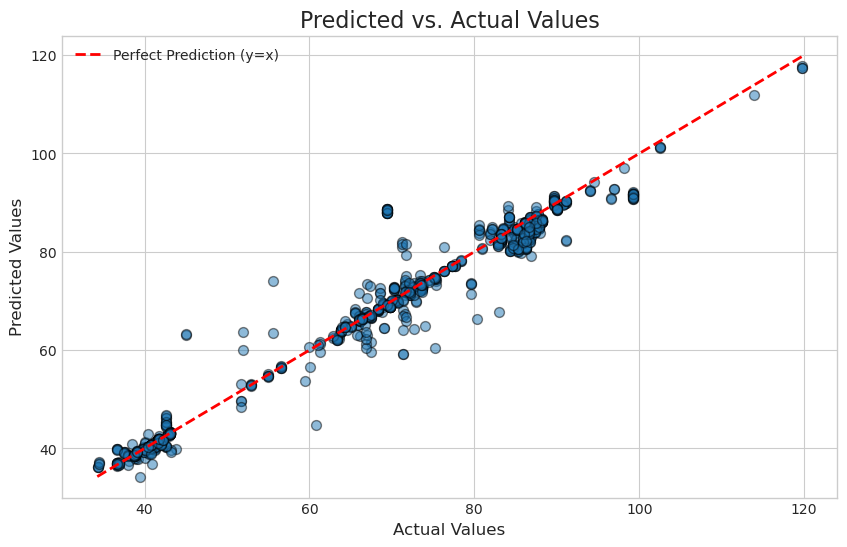

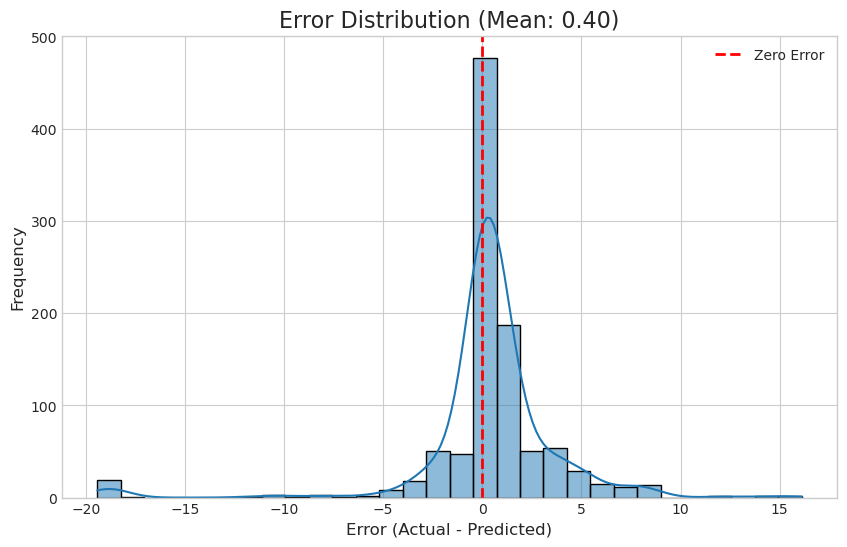

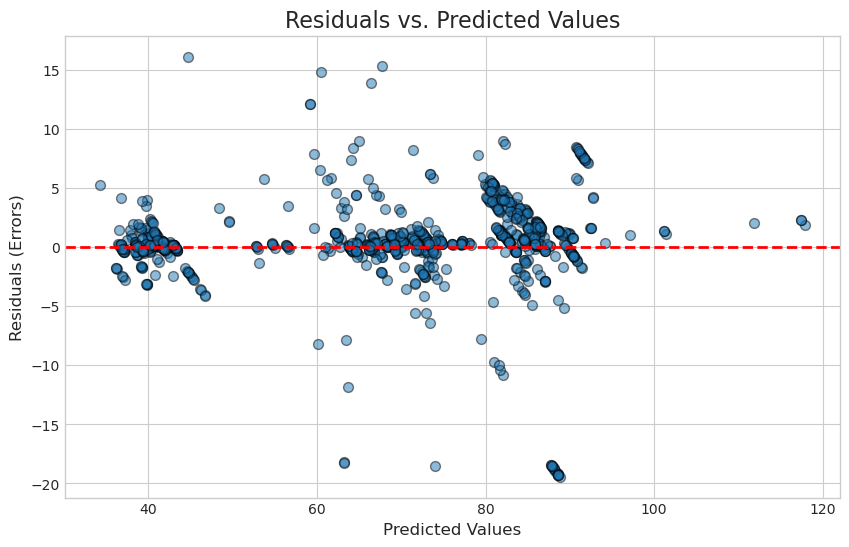

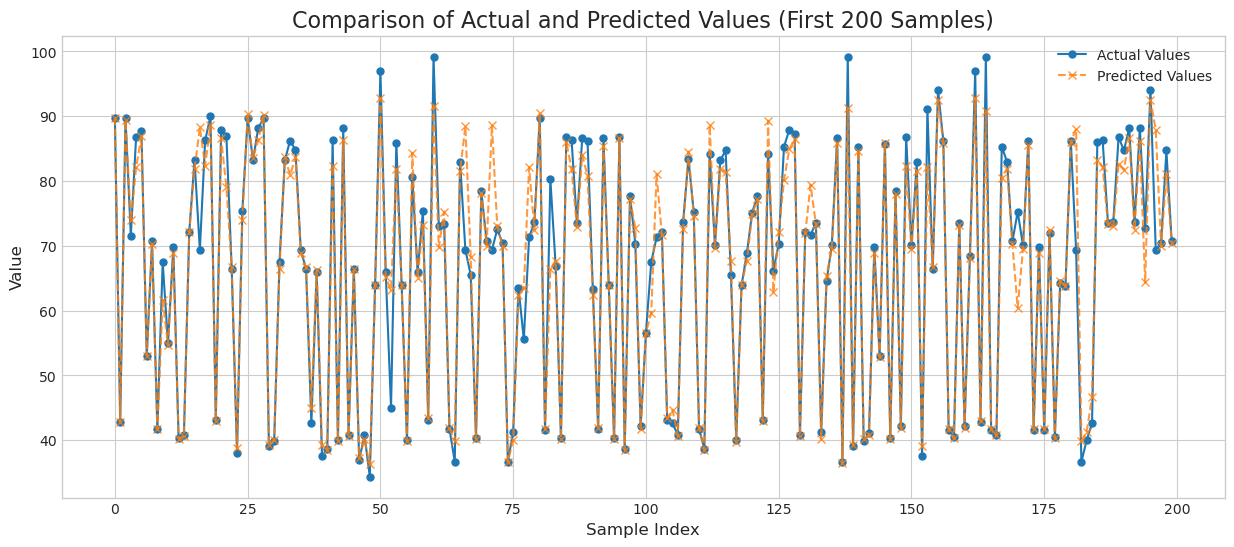

(array([ 89.67    ,  42.86    ,  89.67    ,  71.54    ,  86.78    ,
         87.76    ,  52.92    ,  70.65    ,  41.75    ,  67.49    ,
         54.96    ,  69.79    ,  40.269997,  40.83    ,  72.11    ,
         83.19    ,  69.35    ,  86.24    ,  89.99    ,  43.1     ,
         87.79    ,  86.88    ,  66.38    ,  38.039997,  75.37    ,
         89.67    ,  83.19    ,  88.17    ,  89.67    ,  39.039997,
         39.82    ,  67.51    ,  83.19    ,  86.22    ,  84.75    ,
         69.4     ,  66.38    ,  42.6     ,  65.99    ,  37.48    ,
         38.71    ,  86.24    ,  40.029995,  88.17    ,  40.83    ,
         66.38    ,  36.95    ,  40.76    ,  34.379997,  63.88    ,
         96.96    ,  65.909996,  44.989998,  85.92    ,  63.88    ,
         40.029995,  80.59    ,  65.909996,  75.37    ,  43.129997,
         99.18    ,  72.98    ,  73.37    ,  41.75    ,  36.67    ,
         82.92    ,  69.35    ,  65.5     ,  40.269997,  78.4     ,
         70.65    ,  69.35    ,  72.53    ,  70.

In [1]:
# transformer分析
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 直接根据test_loader_data.pkl中的内容进行分析
def analyze_model_predictions_from_pkl(pkl_path):
    """
    直接从test_loader_data.pkl中读取预测结果和真实值，进行分析和可视化。
    """
    # 读取pkl文件
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
        # 兼容两种格式：dict 或 list
        if isinstance(data, dict):
            # 新版格式
            preds = data["preds"]
            targets = data["targets"]
        elif isinstance(data, list):
            # 旧版格式
            all_inputs = []
            all_targets = []
            for inputs, targets in data:
                all_inputs.append(inputs)
                all_targets.append(targets)
            preds = None  # 没有预测值
            targets = np.concatenate(all_targets, axis=0)
        else:
            raise ValueError("未知的pkl数据格式")
    
    if preds is None:
        print("pkl文件中没有预测值，无法分析")
        return

    actuals = np.array(targets)
    predictions = np.array(preds)
    errors = actuals - predictions

    # 计算R2和误差统计
    r2 = r2_score(actuals, predictions)
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Error Mean: {np.mean(errors):.4f}, Error Std: {np.std(errors):.4f}")

    # 可视化
    plt.style.use('seaborn-v0_8-whitegrid')

    # 图1: 预测值 vs. 真实值 散点图
    plt.figure(figsize=(10, 6))
    plt.scatter(actuals, predictions, alpha=0.5, edgecolors='k', s=50)
    min_val = min(actuals.min(), predictions.min())
    max_val = max(actuals.max(), predictions.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')
    plt.title('Predicted vs. Actual Values', fontsize=16)
    plt.xlabel('Actual Values', fontsize=12)
    plt.ylabel('Predicted Values', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

    # 图2: 误差分布直方图
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True, bins=30)
    plt.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
    plt.title(f'Error Distribution (Mean: {np.mean(errors):.2f})', fontsize=16)
    plt.xlabel('Error (Actual - Predicted)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

    # 图3: 残差图
    plt.figure(figsize=(10, 6))
    plt.scatter(predictions, errors, alpha=0.5, edgecolors='k', s=50)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.title('Residuals vs. Predicted Values', fontsize=16)
    plt.xlabel('Predicted Values', fontsize=12)
    plt.ylabel('Residuals (Errors)', fontsize=12)
    plt.grid(True)
    plt.show()

    # 图4: 真实值与预测值对比折线图
    plt.figure(figsize=(15, 6))
    sample_count = min(len(actuals), 200)
    plt.plot(actuals[:sample_count], label='Actual Values', marker='o', linestyle='-', markersize=5)
    plt.plot(predictions[:sample_count], label='Predicted Values', marker='x', linestyle='--', alpha=0.8)
    plt.title(f'Comparison of Actual and Predicted Values (First {sample_count} Samples)', fontsize=16)
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

    return actuals, predictions, errors

# 使用pkl文件进行分析
#./model/4090V100A6000A800     ; ./model/V100A800/test_loader_data.pkl
analyze_model_predictions_from_pkl('./model/H100_Real/H100_26H100_27H100_28H100_29/test_loader_data_1000Data.pkl')

Chart saved to ./Figures/Evaluation/H100_Real/H-H100_Model_Traning_performance.png


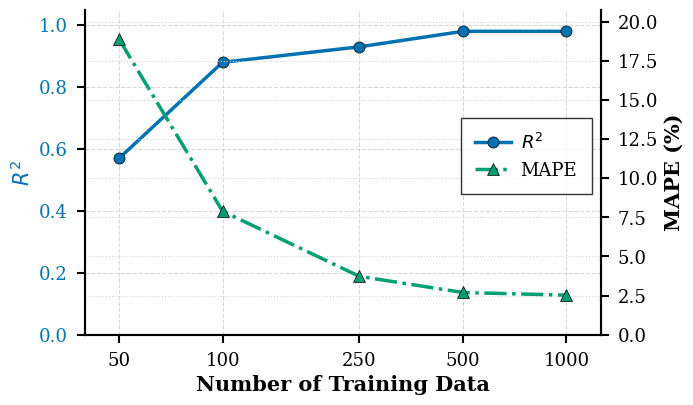

Chart saved to ./Figures/Evaluation/H100_Real/S-H100_Model_Traning_performance.png


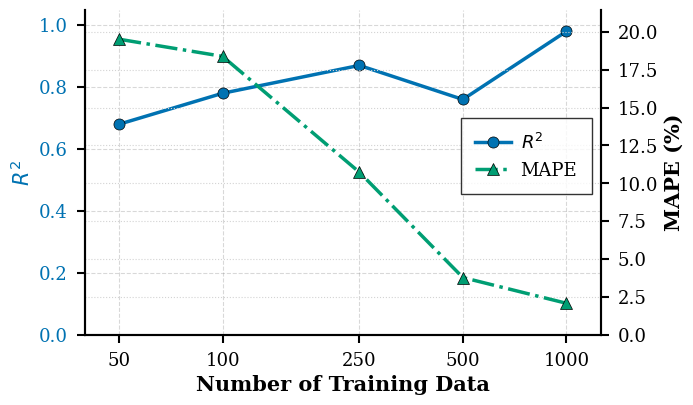

In [ ]:
#按cluster来plot效果
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io

def plot_model_performance(df, cluster_name, save_path=None):
    """
    绘制代理模型在不同训练数据量下的性能指标（R^2, MAPE），横坐标使用log刻度，但显示的依旧是50, 100, 250, 500, 1000。
    注意：MAE数据保留但不绘制。
    """
    # table_data = """
    # Cluster Type,Total GPU,Num of Data,R^2,MAE,MAPE(%)
    # H100,32,50,0.67,7.81,11.84
    # H100,32,100,0.84,4.69,8.15
    # H100,32,250,0.93,3.47,5.67
    # H100,32,500,0.94,3.25,4.84
    # H100,32,1000,0.95,2.82,4.43
    # 4090V100A6000A800,32,50,0.48,1.33,29.10
    # 4090V100A6000A800,32,100,0.85,0.75,15.49
    # 4090V100A6000A800,32,250,0.97,0.22,4.62
    # 4090V100A6000A800,32,500,0.97,0.15,2.61
    # 4090V100A6000A800,32,1000,0.98,0.17,2.61
    # """

    # table_data = """
    # Cluster Type,Total GPU,Num of Data,R^2,MAE,MAPE(%)
    # V100A6000,32,50,0.57,1.53,18.87
    # V100A6000,32,100,0.88,0.77,7.89
    # V100A6000,32,250,0.93,0.37,3.73
    # V100A6000,32,500,0.98,3.1,2.7
    # V100A6000,32,1000,0.98,0.27,2.53
    # 4090A800,32,50,0.68,1.01,19.51
    # 4090A800,32,100,0.78,0.89,18.38
    # 4090A800,32,250,0.87,0.45,10.73
    # 4090A800,32,500,0.76,0.2,3.78
    # 4090A800,32,1000,0.98,0.10,2.08
    # """

    # --- 全局学术风格设置 ---
    plt.rcParams.update({
        'font.family': 'serif',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.linewidth': 1.5,
        'lines.linewidth': 2.5,
    })

    # --- 创建主y轴（R^2） ---
    fig, ax1 = plt.subplots(figsize=(7.2, 4.5), facecolor='none')
    # fig.suptitle(f'Surrogate Model Performance on {cluster_name} Cluster', fontweight='bold', fontsize=16)

    # --- 创建次y轴（MAPE） ---
    ax2 = ax1.twinx()

    # --- 指标及其绘图风格 ---
    metrics_styles = {
        'R^2': {'ax': ax1, 'label': '$R^2$', 'color': '#0072B2', 'marker': 'o', 'linestyle': '-'},
        # 'MAE': {'ax': ax2, 'label': 'MAE', 'color': '#D55E00', 'marker': 's', 'linestyle': '--'}, # 不绘制MAE
        'MAPE(%)': {'ax': ax2, 'label': 'MAPE', 'color': '#009E73', 'marker': '^', 'linestyle': '-.'},
    }

    # --- 只取需要的横坐标点 ---
    xticks = [50, 100, 250, 500, 1000]
    # 保证df中有这些点
    df_plot = df[df['Num of Data'].isin(xticks)].copy()
    # 保证顺序
    df_plot['Num of Data'] = pd.Categorical(df_plot['Num of Data'], categories=xticks, ordered=True)
    df_plot = df_plot.sort_values('Num of Data')

    # 横坐标log变换
    log_xticks = np.log10(xticks)
    log_x = np.log10(df_plot['Num of Data'].astype(float))

    # --- 绘制每个指标 ---
    for metric, style in metrics_styles.items():
        ax = style['ax']
        ax.plot(log_x, df_plot[metric],
                label=style['label'],
                color=style['color'],
                marker=style['marker'],
                linestyle=style['linestyle'],
                markersize=8,
                markeredgecolor='black',
                markeredgewidth=0.5,
                zorder=3)

    # --- 主y轴设置 ---
    ax1.set_ylabel(metrics_styles['R^2']['label'], fontweight='bold', fontsize=15, color=metrics_styles['R^2']['color'])
    ax1.tick_params(axis='y', labelcolor=metrics_styles['R^2']['color'], which='major', labelsize=13, width=1.5, length=6, pad=6)
    ax1.set_ylim(min(0, df_plot['R^2'].min() * 0.9), 1.05)

    # --- 次y轴设置 ---
    ax2.set_ylabel('MAPE (%)', fontweight='bold', fontsize=15)
    ax2.tick_params(axis='y', which='major', labelsize=13, width=1.5, length=6, pad=6)
    y2_max = df_plot['MAPE(%)'].max()
    ax2.set_ylim(0, y2_max * 1.1)

    # --- x轴设置，只显示指定的点，使用log刻度但显示原始标签 ---
    ax1.set_xlabel('Number of Training Data', fontweight='bold', fontsize=15)
    ax1.tick_params(axis='x', which='major', labelsize=13, width=1.5, length=6, pad=6)
    ax1.set_xticks(log_xticks)
    ax1.set_xticklabels([str(x) for x in xticks])
    ax1.set_xlim(log_xticks[0] - 0.1, log_xticks[-1] + 0.1)

    # --- 样式 ---
    ax1.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    for spine in ['top']:
        ax1.spines[spine].set_visible(False)
        ax2.spines[spine].set_visible(False)
    for spine in ['bottom', 'left', 'right']:
        ax1.spines[spine].set_linewidth(1.5)
        ax1.spines[spine].set_color('black')
        ax2.spines[spine].set_linewidth(1.5)
        ax2.spines[spine].set_color('black')

    # --- 合并图例 ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    legend = ax2.legend(lines1 + lines2, labels1 + labels2,
                        frameon=True,
                        loc='center right',
                        bbox_to_anchor=(1, 0.55),
                        fontsize=13,
                        edgecolor='black',
                        fancybox=False,
                        borderpad=0.8,
                        handletextpad=0.5,
                        handlelength=2.0,
                        facecolor='white',
                        framealpha=0.8
                       )
    legend.get_frame().set_linewidth(1.0)

    plt.tight_layout(pad=1.2, rect=[0, 0, 1, 0.96])

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', format='png', transparent=True)
        print(f"Chart saved to {save_path}")

    plt.show()


# --- 主流程 ---

# 1. 解析表格数据
table_data = """
Cluster Type,Total GPU,Num of Data,R^2,MAE,MAPE(%)
H-H100,32,50,0.67,7.81,11.84
H-H100,32,100,0.84,4.69,8.15
H-H100,32,250,0.93,3.47,5.67
H-H100,32,500,0.94,3.25,4.84
H-H100,32,1000,0.95,2.82,4.43
S-H100,32,50,0.24,13.80,28.76
S-H100,32,100,0.27,11.86,22.38
S-H100,32,250,0.44,10.14,17.89
S-H100,32,500,0.63,8.03,14.41
S-H100,32,1000,0.89,4.18,6.51
"""


df_full = pd.read_csv(io.StringIO(table_data))

cluster_type1 = 'V100A6000' #'H-H100'
cluster_type2 = '4090A800' #'S-H100'
# 2. 分离不同集群类型
df_h100 = df_full[df_full['Cluster Type'] == cluster_type1].copy()
df_hetero = df_full[df_full['Cluster Type'] == cluster_type2].copy()

# 3. 绘制H100集群
plot_model_performance(df_h100, cluster_type1, save_path='./Figures/Evaluation/H100_Real/H-H100_Model_Traning_performance.png')

# 4. 绘制异构集群
plot_model_performance(df_hetero, cluster_type2, save_path='./Figures/Evaluation/H100_Real/S-H100_Model_Traning_performance.png')


Chart saved to ./Figures/Evaluation/H100_Real/Ablation_Transformer_Model_Performance.png


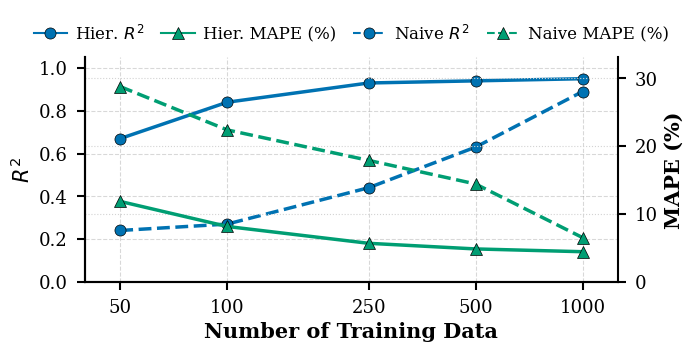

In [64]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import os
# ********************** 主要新增导入 **********************
from matplotlib.lines import Line2D 

def plot_combined_performance_v2(df1, cluster1_name, df2, cluster2_name, save_path=None):
    """
    在一张图上绘制两个集群的代理模型性能指标（R^2, MAPE），并统一画风。
    - 使用颜色区分不同的性能指标 (Metric)。
    - 使用线型区分不同的集群 (Cluster)。
    - 横坐标使用log刻度，但显示的依旧是50, 100, 250, 500, 1000。
    """

    # --- 全局学术风格设置 (与目标风格统一) ---
    plt.rcParams.update({
        'font.family': 'serif',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.linewidth': 1.5,
        'lines.linewidth': 1.5,
    })

    # --- 创建画布和坐标轴 (与目标风格统一) ---
    fig, ax1 = plt.subplots(figsize=(7.2, 4), facecolor='none')
    ax2 = ax1.twinx()

    # --- 定义样式 ---
    cluster_styles = {
        cluster1_name: {'linestyle': '-', 'name': cluster1_name},
        cluster2_name: {'linestyle': '--', 'name': cluster2_name}
    }
    
    metrics_styles = {
        'R^2': {'ax': ax1, 'label': '$R^2$', 'marker': 'o', 'color': '#0072B2'},
        'MAPE(%)': {'ax': ax2, 'label': 'MAPE (%)', 'marker': '^', 'color': '#009E73'}
    }

    # --- 横坐标刻度 ---
    xticks = [50, 100, 250, 500, 1000]
    log_xticks = np.log10(xticks)

    # --- 循环绘制每个集群的每个指标 --- 
    data_to_plot = {cluster1_name: df1, cluster2_name: df2}
    
    for cluster_name, df in data_to_plot.items():
        df_plot = df[df['Num of Data'].isin(xticks)].copy()
        df_plot['Num of Data'] = pd.Categorical(df_plot['Num of Data'], categories=xticks, ordered=True)
        df_plot = df_plot.sort_values('Num of Data')
        log_x = np.log10(df_plot['Num of Data'].astype(float))

        for metric, m_style in metrics_styles.items():
            ax = m_style['ax']
            c_style = cluster_styles[cluster_name]
            
            # 注意：在绘图时我们不再需要 legend_label，因为图例是手动创建的
            # legend_label = f"{c_style['name']} {m_style['label']}"
            
            ax.plot(log_x, df_plot[metric],
                      # label=legend_label,  # 移除这里的label
                      color=m_style['color'],
                      marker=m_style['marker'],
                      linestyle=c_style['linestyle'],
                      linewidth=2.5,
                      markersize=8,
                      markeredgecolor='black',
                      markeredgewidth=0.5,
                      # markevery=4, # 您的数据点少，为了演示效果暂时注释
                      zorder=3)

    # --- Y轴范围设置 ---
    all_mape = pd.concat([df1['MAPE(%)'], df2['MAPE(%)']])

    # --- 主y轴设置 (R^2) ---
    ax1.set_ylabel(metrics_styles['R^2']['label'], fontweight='bold', fontsize=15)
    ax1.tick_params(axis='y', which='major', labelsize=13, width=1.5, length=6, pad=6, labelcolor='black')
    ax1.set_ylim(0, 1.05)

    # --- 次y轴设置 (MAPE) ---
    ax2.set_ylabel(metrics_styles['MAPE(%)']['label'], fontweight='bold', fontsize=15)
    ax2.tick_params(axis='y', which='major', labelsize=13, width=1.5, length=6, pad=6, labelcolor='black')
    ax2.set_ylim(0, all_mape.max() * 1.15)

    # --- x轴设置 ---
    ax1.set_xlabel('Number of Training Data', fontweight='bold', fontsize=15)
    ax1.tick_params(axis='x', which='major', labelsize=13, width=1.5, length=6, pad=6)
    ax1.set_xticks(log_xticks)
    ax1.set_xticklabels([str(x) for x in xticks])
    ax1.set_xlim(log_xticks[0] - 0.1, log_xticks[-1] + 0.1)

    # --- 通用样式 ---
    ax1.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('black')
    ax1.spines['bottom'].set_color('black')
    ax2.spines['right'].set_visible(True)
    ax2.spines['right'].set_color('black')
    
    # ********************** 主要修改点：手动创建图例 **********************
    
    legend_elements = []
    labels_in_order = []

    # 按照期望的顺序（或任何你想要的顺序）构建图例元素
    for cluster_name in [cluster1_name, cluster2_name]:
        for metric_name in ['R^2', 'MAPE(%)']:
            c_style = cluster_styles[cluster_name]
            m_style = metrics_styles[metric_name]
            
            # 构建标签
            label_text = f"{c_style['name']} {m_style['label']}"
            labels_in_order.append(label_text)
            
            # 创建一个Line2D对象作为图例的“代理”
            # 它有我们想要的所有样式，但没有实际数据
            legend_elements.append(Line2D([0], [0], 
                                          color=m_style['color'], 
                                          linestyle=c_style['linestyle'],
                                          marker=m_style['marker'],
                                          markersize=8,
                                          markeredgecolor='black',
                                          markeredgewidth=0.5,
                                          label=label_text))

    # 使用手动创建的元素来生成图例
    legend = ax1.legend(handles=legend_elements,
                        loc='upper center', 
                        bbox_to_anchor=(0.5, 1.25),
                        ncol=4,
                        frameon=False,
                        fontsize=12,
                        handletextpad=0.5,
                        borderpad=0.8,
                        handlelength=2.0,
                        columnspacing=1.0,
                       )

    plt.tight_layout(pad=1.2)

    # --- 保存图像 ---
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir and not os.path.exists(save_dir):
            os.makedirs(save_dir)
            print(f"Created directory: {save_dir}")
        
        plt.savefig(save_path, bbox_inches='tight', format='png', transparent=True, dpi=300)
        print(f"Chart saved to {save_path}")

    plt.show()


# --- 主流程 (保持不变) ---

# 1. 解析表格数据
table_data = """
Cluster Type,Total GPU,Num of Data,R^2,MAE,MAPE(%)
Hier.,32,50,0.67,7.81,11.84
Hier.,32,100,0.84,4.69,8.15
Hier.,32,250,0.93,3.47,5.67
Hier.,32,500,0.94,3.25,4.84
Hier.,32,1000,0.95,2.82,4.43
Naive,32,50,0.24,13.80,28.76
Naive,32,100,0.27,11.86,22.38
Naive,32,250,0.44,10.14,17.89
Naive,32,500,0.63,8.03,14.41
Naive,32,1000,0.89,4.18,6.51
"""

df_full = pd.read_csv(io.StringIO(table_data))

cluster_type1 = 'Hier.'
cluster_type2 = 'Naive'

# 2. 分离不同集群类型
df_h100 = df_full[df_full['Cluster Type'] == cluster_type1].copy()
df_hetero = df_full[df_full['Cluster Type'] == cluster_type2].copy()

# 3. 调用新的绘图函数
plot_combined_performance_v2(
    df1=df_h100, 
    cluster1_name=cluster_type1, 
    df2=df_hetero, 
    cluster2_name=cluster_type2, 
    save_path='./Figures/Evaluation/H100_Real/Ablation_Transformer_Model_Performance.png'
)

--- 开始分析模型性能: ./model/4090V100A6000A800H100/test_loader_data_1000Data.pkl ---

--- 模型性能评估指标 ---
R-squared (R²): 0.9103
  - 学术解读: 模型解释了因变量 91.03% 的方差。值越接近1越好。
Mean Absolute Error (MAE): 0.1847
  - 学术解读: 平均而言，模型的预测值与真实值相差 0.1847。
Mean Absolute Percentage Error (MAPE): 4.00%
  - 学术解读: 平均而言，模型的预测误差占真实值的 4.00%。
Error Mean (Bias): 0.0622
  - 学术解读: 误差均值，理想情况下应接近0，表明模型无系统性高估或低估。
Error Std Dev: 0.6864
  - 学术解读: 误差的标准差，衡量预测稳定性。值越小，模型预测越稳定。
---------------------------

图表已保存至: Figures/Evaluation/4090V100A6000A800H100/1000Data_model_diagnostics.pdf


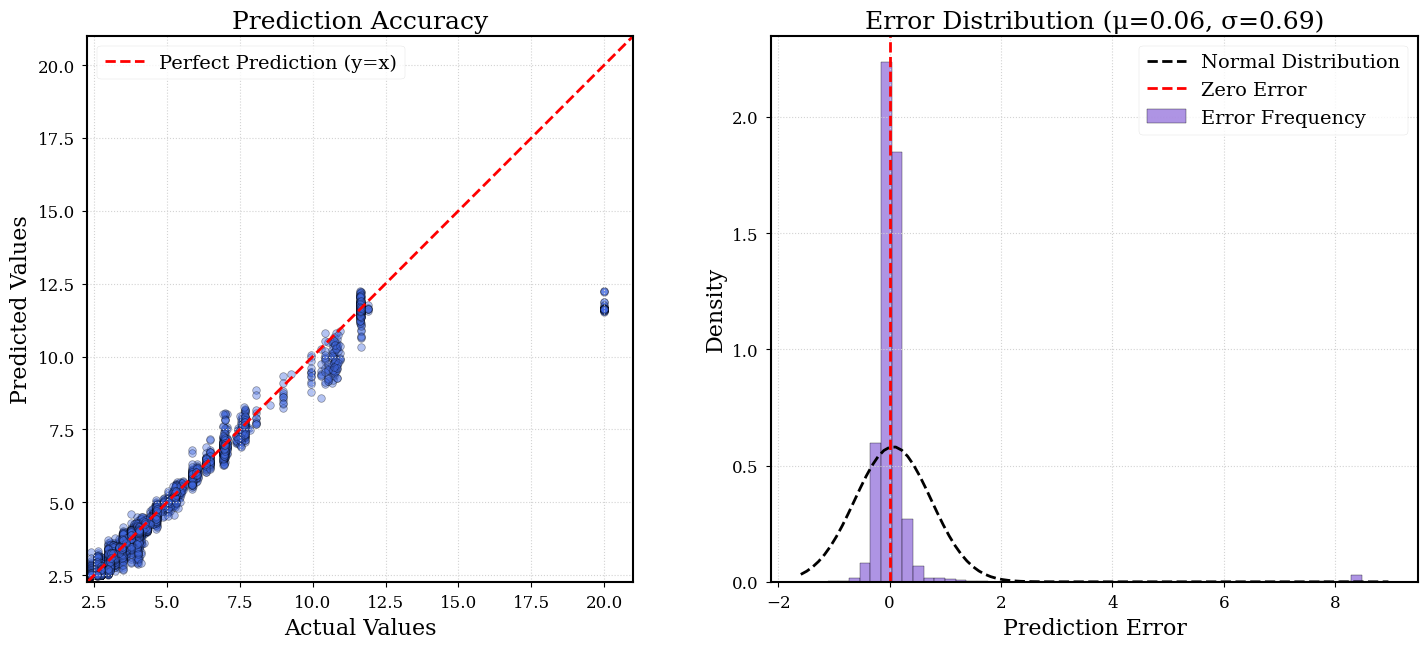

In [12]:
#分析模型性能
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error
import scipy.stats as stats 

def plot_model_diagnostics(actuals: np.ndarray, predictions: np.ndarray, errors: np.ndarray, save_path: str = None):
    """
    生成一套符合学术出版标准的模型诊断图 (2x2布局)。
    
    Args:
        actuals (np.ndarray): 真实值.
        predictions (np.ndarray): 模型的预测值.
        errors (np.ndarray): 误差 (actuals - predictions).
        save_path (str, optional): 图片保存路径. 如果提供，则保存图表.
    """
    # --- 设置学术风格的图表参数 ---
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif',
        # 'font.sans-serif': ['Arial', 'Helvetica'], # 使用常见无衬线字体
        'font.size': 14,
        'axes.labelsize': 16,
        'axes.titlesize': 18,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 14,
        'figure.titlesize': 20,
        'lines.linewidth': 2,
        'axes.grid': True,
        'grid.linestyle': ':',
        'grid.color': 'lightgray',
        'pdf.fonttype': 42,      # 确保PDF中字体正确嵌入
        'ps.fonttype': 42,
        'axes.linewidth': 1.5,   # 加粗轴线
    })
    fig, axes = plt.subplots(1, 2, figsize=(15,7))
    # fig.suptitle('Hierarchical-Transformer Performance Diagnostics', fontweight='bold')

    # --- 1. 预测值 vs. 真实值 (Predicted vs. Actual) ---
    # 学术意义: 评估模型预测的整体准确性和一致性。点越接近对角线y=x，说明模型性能越好。
    ax1 = axes[0]
    ax1.scatter(actuals, predictions, alpha=0.4, s=30, edgecolors='k', linewidth=0.5, c='royalblue')
    min_val = min(actuals.min(), predictions.min()) * 0.95
    max_val = max(actuals.max(), predictions.max()) * 1.05
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction (y=x)')
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Predicted Values')
    ax1.set_title('Prediction Accuracy')
    ax1.legend(loc='upper left')
    ax1.axis('square') # 强制为正方形，使y=x线为45度角
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)


    # # --- 2. 残差图 (Residuals vs. Predicted) ---
    # # 学术意义: 检查误差是否随预测值的变化而呈现某种模式（异方差性）。
    # # 一个好的模型，其残差应随机分布在y=0水平线两侧，无明显趋势。
    # ax2 = axes[0, 1]
    # ax2.scatter(predictions, errors, alpha=0.4, s=30, edgecolors='k', linewidth=0.5, c='forestgreen')
    # ax2.axhline(y=0, color='r', linestyle='--')
    # ax2.set_xlabel('Predicted Values')
    # ax2.set_ylabel('Residuals (Actual - Predicted)')
    # ax2.set_title('Residual Analysis')

    # --- 3. 误差分布直方图 (Error Distribution) ---
    # 学术意义: 观察误差的分布形态。理想情况下，误差应呈正态分布，均值为0。
    # 这表明模型的误差是随机的，而不是系统性的偏差。
    ax3 = axes[1]
    sns.histplot(errors, kde=False, bins=50, ax=ax3, color='mediumpurple', stat='density', label='Error Frequency')
    # 拟合正态分布曲线
    mu, std = stats.norm.fit(errors)
    xmin, xmax = ax3.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax3.plot(x, p, 'k--', linewidth=2, label='Normal Distribution')
    ax3.axvline(x=0, color='r', linestyle='--', label='Zero Error')
    ax3.set_xlabel('Prediction Error')
    ax3.set_ylabel('Density')
    ax3.set_title(f'Error Distribution (μ={mu:.2f}, σ={std:.2f})')
    ax3.legend(loc='upper right')

    # # --- 4. Q-Q 图 (Quantile-Quantile Plot) ---
    # # 学术意义: 严格检验误差是否服从正态分布。
    # # 如果点紧密地排列在45度参考线上，则表明误差是正态分布的。
    # ax4 = axes[1, 1]
    # stats.probplot(errors, dist="norm", plot=ax4)
    # ax4.get_lines()[0].set_markerfacecolor('darkorange')
    # ax4.get_lines()[0].set_markeredgecolor('k')
    # ax4.get_lines()[0].set_markersize(5.0)
    # ax4.get_lines()[1].set_color('r')
    # ax4.set_xlabel('Theoretical Quantiles (Normal)')
    # ax4.set_ylabel('Sample Quantiles (Errors)')
    # ax4.set_title('Normality of Residuals (Q-Q Plot)')

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # 调整布局以适应主标题

    if save_path:
        # 保存为高分辨率矢量图，便于论文排版
        plt.savefig(save_path, dpi=300, format='pdf', bbox_inches='tight')
        print(f"图表已保存至: {save_path}")
        
    plt.show()


def analyze_model_performance(pkl_path: str, save_fig_path: str = "model_diagnostics.pdf"):
    """
    从 .pkl 文件加载数据，计算关键性能指标，并生成一套专业的模型诊断图。

    Args:
        pkl_path (str): 包含 'preds' 和 'targets' 的 .pkl 文件路径。
        save_fig_path (str, optional): 生成的诊断图表的保存路径。
    """
    print(f"--- 开始分析模型性能: {pkl_path} ---")
    
    # 读取 .pkl 文件
    try:
        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
    except FileNotFoundError:
        print(f"错误: 文件未找到 at '{pkl_path}'")
        return

    if isinstance(data, dict) and "preds" in data and "targets" in data:
        predictions = np.array(data["preds"]).flatten()
        actuals = np.array(data["targets"]).flatten()
    else:
        print("错误: pkl文件格式不兼容。需要一个包含'preds'和'targets'键的字典。")
        return

    if actuals.shape != predictions.shape:
        print(f"错误: 真实值和预测值的形状不匹配。Actuals: {actuals.shape}, Predictions: {predictions.shape}")
        return
        
    # 避免在计算MAPE时除以零
    zero_mask = actuals == 0
    if np.any(zero_mask):
        print(f"警告: 真实值中包含 {np.sum(zero_mask)} 个零，将在MAPE计算中被忽略。")
        actuals_mape = actuals[~zero_mask]
        predictions_mape = predictions[~zero_mask]
    else:
        actuals_mape = actuals
        predictions_mape = predictions

    # --- 计算关键性能指标 ---
    errors = actuals - predictions
    r2 = r2_score(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals_mape - predictions_mape) / actuals_mape)) * 100 if len(actuals_mape) > 0 else float('nan')
    
    print("\n--- 模型性能评估指标 ---")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"  - 学术解读: 模型解释了因变量 {r2:.2%} 的方差。值越接近1越好。")
    
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  - 学术解读: 平均而言，模型的预测值与真实值相差 {mae:.4f}。")

    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"  - 学术解读: 平均而言，模型的预测误差占真实值的 {mape:.2f}%。")

    print(f"Error Mean (Bias): {np.mean(errors):.4f}")
    print(f"  - 学术解读: 误差均值，理想情况下应接近0，表明模型无系统性高估或低估。")
    
    print(f"Error Std Dev: {np.std(errors):.4f}")
    print(f"  - 学术解读: 误差的标准差，衡量预测稳定性。值越小，模型预测越稳定。")
    print("---------------------------\n")

    # --- 生成并显示/保存图表 ---
    plot_model_diagnostics(actuals, predictions, errors, save_path=save_fig_path)

# --- 使用示例 ---
# 请将下面的路径替换为您的 .pkl 文件路径
# 推荐的文件名格式: [模型名称]_[数据集]_diagnostics.pdf   ,V100A800
PKL_FILE_PATH = './model/4090V100A6000A800H100/test_loader_data_1000Data.pkl'
FIGURE_SAVE_PATH = 'Figures/Evaluation/4090V100A6000A800H100/1000Data_model_diagnostics.pdf' # 保存为PDF格式，确保论文排版质量

analyze_model_performance(PKL_FILE_PATH, save_fig_path=FIGURE_SAVE_PATH)


## End-to-End Dispatching Performance

The mean of the UpperBandDisp is : 83.26522083324913
The mean of the BandDisp is : 80.62752967038624
The mean of the Topo is : 46.255135776709544
The mean of the Default is : 38.009115230780736
The mean of the Random is : 34.68261717438835
Chart saved to ./Figures/Evaluation/test.png


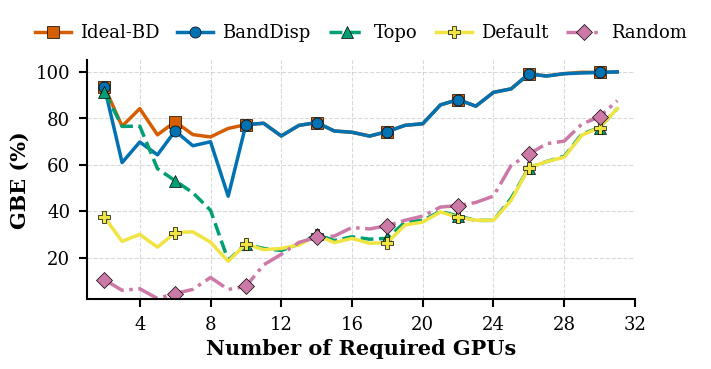

In [4]:
# 算法对比图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# 系统论文风格的全局设置
plt.rcParams.update({
    'font.family': 'serif',  # 系统论文常用的字体族
    'pdf.fonttype': 42,      # 确保PDF中字体正确嵌入
    'ps.fonttype': 42,
    'axes.linewidth': 1.5,   # 加粗轴线
    'lines.linewidth': 1.5,  # 加粗曲线
})

def plot_algorithm_performance(data_path, total_gpu=None, bw_type=None, cluster_type=None, if_dynamic=None,
                               if_my=True, if_topo=True, save_path=None):
    # 读取数据
    df = pd.read_csv(data_path)
    df['UpperBandDisp'] = np.maximum(df['UpperBandDisp'], df['BandDisp'])

    # 应用指定的筛选条件
    if total_gpu is not None:
        df = df[df['total_gpu'] == total_gpu]
    if bw_type is not None:
        df = df[df['bw_type'] == bw_type]
    if cluster_type is not None:
        df = df[df['cluster_type'] == cluster_type]
    if if_dynamic is not None:
        df = df[df['if_dynamic'] == if_dynamic]
    
    # 按test_num排序，确保线条正确绘制
    df = df.sort_values(by='test_num')
    
    # 定义要绘制的算法及其样式
    # 使用色盲友好的调色板
    algorithms = {
        'UpperBandDisp': {'label': 'Ideal-BD', 'color': '#D55E00', 'marker': 's', 'linestyle': '-', 'include': True},
        'BandDisp': {'label': 'BandDisp', 'color': '#0072B2', 'marker': 'o', 'linestyle': '-', 'include': if_my},
        'Topo': {'label': 'Topo', 'color': '#009E73', 'marker': '^', 'linestyle': '--', 'include': if_topo},
        'Default': {'label': 'Default', 'color': '#F0E442', 'marker': 'P', 'linestyle': '-', 'include': True},  # 黄色，五边形，实线
        'Random': {'label': 'Random', 'color': '#CC79A7', 'marker': 'D', 'linestyle': '-.', 'include': True},
        # 'Tree': {'label': 'PTS', 'color': '#009E73', 'marker': 'P', 'linestyle': '-', 'include': True},  # 黄色，五边形，实线
        # 'EHA': {'label': 'EHA', 'color': '#D55E00', 'marker': 'X', 'linestyle': '-', 'include': True},  # 浅蓝色，X形，虚线
    }
    
    # 创建高分辨率的图形，尺寸适合出版要求，设置透明背景
    fig, ax = plt.subplots(figsize=(7.2, 4), facecolor='none')
    
    # 绘制每个算法
    for algo, style in algorithms.items():
        if style['include']:
            print(f"The mean of the {algo} is : {np.mean(df[algo])}")
            ax.plot(df['test_num'], df[algo], 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
    
    # 自定义坐标轴
    ax.set_xlabel('Number of Required GPUs', fontweight='bold', fontsize=15)
    ax.set_ylabel('GBE (%)', fontweight='bold', fontsize=15)
    
    # 设置x轴仅显示整数值
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 设置X轴限制 - 基于数据动态计算，并添加一些边距
    min_x_data = np.min(df['test_num'])
    max_x_data = np.max(df['test_num'])
    ax.set_xlim(min_x_data - 1, max_x_data + 1)
    
    # 计算y轴范围，添加适当的留白
    y_min = max(0, df[list(a for a, s in algorithms.items() if s['include'])].min().min() * 0.95)
    y_max = min(105, df[list(a for a, s in algorithms.items() if s['include'])].max().max() * 1.05)
    ax.set_ylim(y_min, y_max)
    
    # 自定义网格 - 更淡且位于数据后面
    ax.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    
    # 增强轴脊
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    
    # 自定义刻度
    ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6, pad=6)
    
    # 计算要显示的图例数量
    included_algorithms_count = sum(1 for algo in algorithms.values() if algo['include'])

    # 将图例放置在图表上方
    legend = ax.legend(
        loc='upper center',          # 定位在顶部中心
        bbox_to_anchor=(0.5, 1.25),  # 调整位置到图表区域之上
        ncol=included_algorithms_count, # 水平排列图例项
        frameon=False,               # 移除边框以获得更简洁的外观
        fontsize=13,                 # 增大图例字体
        handletextpad=0.5,
        borderpad=0.8,  
        handlelength=2.0,
        columnspacing=1.0,
    )
    # 添加带有增强样式的图例，设置透明背景
    # legend = ax.legend(
    #     frameon=True, 
    #     loc='center', 
    #     fontsize=13,          # 增大图例字体
    #     edgecolor='black',
    #     fancybox=False,
    #     borderpad=0.8,
    #     handletextpad=0.5,
    #     handlelength=2.0,
    #     columnspacing=1.0,
    #     facecolor='none'      # 设置图例背景透明
    # )
    # legend.get_frame().set_linewidth(1.0)
    # legend.get_frame().set_alpha(0.9)
    
    # 添加微妙的边框，营造学术感
    for spine in ax.spines.values():
        spine.set_zorder(10)
    
    # 紧凑布局优化间距
    plt.tight_layout(pad=1.2)
    
    # 如果提供路径，保存图形为PNG格式
    if save_path:
        # 将文件扩展名改为.png
        png_save_path = save_path.rsplit('.', 1)[0] + '.png'
        plt.savefig(png_save_path, bbox_inches='tight', format='png', transparent=True)
        print(f"Chart saved to {png_save_path}")
    
    plt.show()

#Het-4Mix  #H100_26H100_27H100_28H100_29
plot_algorithm_performance('./Data/Evaluation/H100_Real/Het-4Mix/Part_mean_1111_bw_32dim_dynamicTrue.csv',
                           total_gpu=None, 
                           bw_type=None, 
                           cluster_type=None, 
                           if_dynamic=True,
                           if_my=True, 
                           if_topo=True, #4090V100A6000A800/Ablation-Performance-Baseline-250Data.pdf
                           save_path="./Figures/Evaluation/test.pdf")# 4090A800/Performance-Baseline-250Data.pdf

The mean of the UpperBandDisp is : 17.00660384506703
The mean of the BandDisp is : 17.242829744372933
The mean of the Topo is : 9.184777367972751
The mean of the Default is : 5.996413012419763
The mean of the Random is : 3.7615892992222384


FileNotFoundError: [Errno 2] No such file or directory: '/home/ldaphome/zkm/Project/GPU_Dispatching/SC_BandPilot/Figures/Evaluation/H100_Real/Performance-Sum-Baseline-250Data.png'

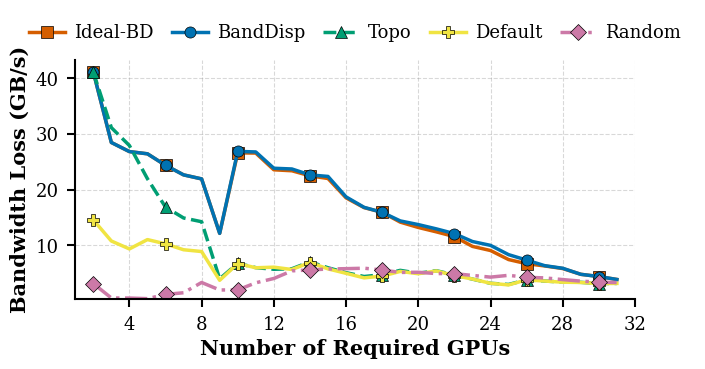

In [7]:
# 算法accumulate对比图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# 系统论文风格的全局设置
plt.rcParams.update({
    'font.family': 'serif',  # 系统论文常用的字体族
    'pdf.fonttype': 42,      # 确保PDF中字体正确嵌入
    'ps.fonttype': 42,
    'axes.linewidth': 1.5,   # 加粗轴线
    'lines.linewidth': 1.5,  # 加粗曲线
})

def plot_algorithm_performance(data_path, total_gpu=None, bw_type=None, cluster_type=None, if_dynamic=None,
                               if_my=True, if_topo=True, save_path=None):
    # 读取数据
    df = pd.read_csv(data_path)
    df['UpperBandDisp'] = np.minimum(df['UpperBandDisp'], df['BandDisp'])

    # 应用指定的筛选条件
    if total_gpu is not None:
        df = df[df['total_gpu'] == total_gpu]
    if bw_type is not None:
        df = df[df['bw_type'] == bw_type]
    if cluster_type is not None:
        df = df[df['cluster_type'] == cluster_type]
    if if_dynamic is not None:
        df = df[df['if_dynamic'] == if_dynamic]
    
    # 按test_num排序，确保线条正确绘制
    df = df.sort_values(by='test_num')
    
    # 定义要绘制的算法及其样式
    # 使用色盲友好的调色板
    algorithms = {
        'UpperBandDisp': {'label': 'Ideal-BD', 'color': '#D55E00', 'marker': 's', 'linestyle': '-', 'include': True},
        'BandDisp': {'label': 'BandDisp', 'color': '#0072B2', 'marker': 'o', 'linestyle': '-', 'include': if_my},
        'Topo': {'label': 'Topo', 'color': '#009E73', 'marker': '^', 'linestyle': '--', 'include': if_topo},
        'Default': {'label': 'Default', 'color': '#F0E442', 'marker': 'P', 'linestyle': '-', 'include': True},  # 黄色，五边形，实线
        'Random': {'label': 'Random', 'color': '#CC79A7', 'marker': 'D', 'linestyle': '-.', 'include': True},
        # 'Tree_search': {'label': 'Tree_search', 'color': '#F0E442', 'marker': 'P', 'linestyle': '-', 'include': True},  # 黄色，五边形，实线
        # 'EHA': {'label': 'EHA', 'color': '#56B4E9', 'marker': 'X', 'linestyle': '--', 'include': True},  # 浅蓝色，X形，虚线
    }
    
    # 创建高分辨率的图形，尺寸适合出版要求，设置透明背景
    fig, ax = plt.subplots(figsize=(7.2, 4), facecolor='none')
    
    # 绘制每个算法
    for algo, style in algorithms.items():
        if style['include']:
            print(f"The mean of the {algo} is : {np.mean(df[algo])}")
            ax.plot(df['test_num'], df[algo], 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
    
    # 自定义坐标轴
    ax.set_xlabel('Number of Required GPUs', fontweight='bold', fontsize=15)
    ax.set_ylabel('Bandwidth Loss (GB/s)', fontweight='bold', fontsize=15)
    
    # 设置x轴仅显示整数值
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 设置X轴限制 - 基于数据动态计算，并添加一些边距
    min_x_data = np.min(df['test_num'])
    max_x_data = np.max(df['test_num'])
    ax.set_xlim(min_x_data - 1, max_x_data + 1)
    
    # 计算y轴范围，添加适当的留白
    y_min = max(0, df[list(a for a, s in algorithms.items() if s['include'])].min().min() * 0.95)
    y_max = min(105, df[list(a for a, s in algorithms.items() if s['include'])].max().max() * 1.05)
    ax.set_ylim(y_min, y_max)
    
    # 自定义网格 - 更淡且位于数据后面
    ax.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    
    # 增强轴脊
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    
    # 自定义刻度
    ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6, pad=6)
    

    # 计算要显示的图例数量
    included_algorithms_count = sum(1 for algo in algorithms.values() if algo['include'])

    # 将图例放置在图表上方
    legend = ax.legend(
        loc='upper center',          # 定位在顶部中心
        bbox_to_anchor=(0.5, 1.25),  # 调整位置到图表区域之上
        ncol=included_algorithms_count, # 水平排列图例项
        frameon=False,               # 移除边框以获得更简洁的外观
        fontsize=13,                 # 增大图例字体
        handletextpad=0.5,
        borderpad=0.8,  
        handlelength=2.0,
        columnspacing=1.0,
    )
    # 添加带有增强样式的图例，设置透明背景
    # legend = ax.legend(
    #     frameon=True, 
    #     loc='center', 
    #     fontsize=13,          # 增大图例字体
    #     edgecolor='black',
    #     fancybox=False,
    #     borderpad=0.8,
    #     handletextpad=0.5,
    #     handlelength=2.0,
    #     columnspacing=1.0,
    #     facecolor='none'      # 设置图例背景透明
    # )
    legend.get_frame().set_linewidth(1.0)
    legend.get_frame().set_alpha(0.9)
    
    # 添加微妙的边框，营造学术感
    for spine in ax.spines.values():
        spine.set_zorder(10)
    
    # 紧凑布局优化间距
    plt.tight_layout(pad=1.2)
    
    # 如果提供路径，保存图形为PNG格式
    if save_path:
        # 将文件扩展名改为.png
        png_save_path = save_path.rsplit('.', 1)[0] + '.png'
        plt.savefig(png_save_path, bbox_inches='tight', format='png', transparent=True)
        print(f"Chart saved to {png_save_path}")
    
    plt.show()

# 示例用法:H100_Real , 4090V100A6000A800,V100A800,A6000A800,V100A6000     ; noaddT, addT2, addT, noHHCA,HHCA, _2000Data,_1000Data
# 有些数据只有H100有
plot_algorithm_performance('./Data/Evaluation/H100_Real/Het-4Mix/Part_mean_1111_bw_32dim_dynamicTrue.csv',
                           total_gpu=None, 
                           bw_type=None, 
                           cluster_type=None, 
                           if_dynamic=True,
                           if_my=True, 
                           if_topo=True, 
                           save_path="./Figures/Evaluation/H100_Real/Performance-Sum-Baseline-250Data.pdf") # V100A6000/Performance-Sum-Baseline-250Data.pdf

The mean of the BandDisp is : 17.73793555844621
The mean of the Topo is : 9.54126560137164
The mean of the Tree is : 9.713581208144785
The mean of the EHA is : 17.565674283464734
Chart saved to ./Figures/Evaluation/test.png


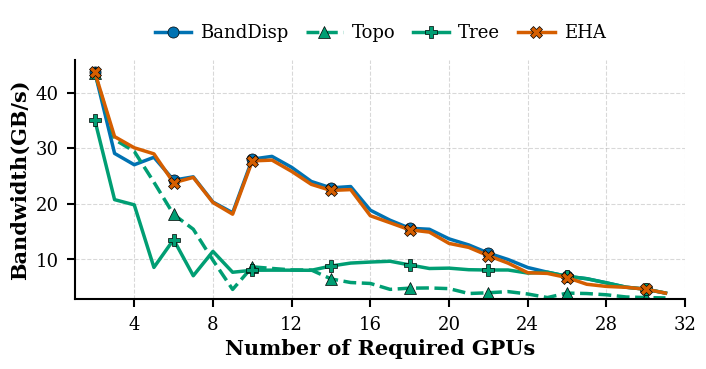

In [12]:
#EHA对比图
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# 系统论文风格的全局设置
plt.rcParams.update({
    'font.family': 'serif',  # 系统论文常用的字体族
    'pdf.fonttype': 42,      # 确保PDF中字体正确嵌入
    'ps.fonttype': 42,
    'axes.linewidth': 1.5,   # 加粗轴线
    'lines.linewidth': 1.5,  # 加粗曲线
})

def plot_algorithm_performance(data_path, total_gpu=None, bw_type=None, cluster_type=None, if_dynamic=None,
                               if_my=True, if_topo=True, save_path=None):
    # 读取数据
    df = pd.read_csv(data_path)
    # df['UpperBandDisp'] = np.maximum(df['UpperBandDisp'], df['BandDisp'])

    # 应用指定的筛选条件
    if total_gpu is not None:
        df = df[df['total_gpu'] == total_gpu]
    if bw_type is not None:
        df = df[df['bw_type'] == bw_type]
    if cluster_type is not None:
        df = df[df['cluster_type'] == cluster_type]
    if if_dynamic is not None:
        df = df[df['if_dynamic'] == if_dynamic]
    # 筛选test_num在20-128之间的数据
    df = df[(df['test_num'] >= 2) & (df['test_num'] <= 128)]
    # 按test_num排序，确保线条正确绘制
    df = df.sort_values(by='test_num')
    
    # 定义要绘制的算法及其样式
    # 使用色盲友好的调色板
    algorithms = {
        # 'UpperBandDisp': {'label': 'Ideal-BD', 'color': '#D55E00', 'marker': 's', 'linestyle': '-', 'include': True},
        'BandDisp': {'label': 'BandDisp', 'color': '#0072B2', 'marker': 'o', 'linestyle': '-', 'include': if_my},
        'Topo': {'label': 'Topo', 'color': '#009E73', 'marker': '^', 'linestyle': '--', 'include': if_topo},
        # 'Default': {'label': 'Default', 'color': '#F0E442', 'marker': 'P', 'linestyle': '-', 'include': True},  # 黄色，五边形，实线
        # 'Random': {'label': 'Random', 'color': '#CC79A7', 'marker': 'D', 'linestyle': '-.', 'include': True},
        'Tree': {'label': 'Tree', 'color': '#009E73', 'marker': 'P', 'linestyle': '-', 'include': True},  # 黄色，五边形，实线
        'EHA': {'label': 'EHA', 'color': '#D55E00', 'marker': 'X', 'linestyle': '-', 'include': True},  # 浅蓝色，X形，虚线
    }
    
    # 创建高分辨率的图形，尺寸适合出版要求，设置透明背景
    fig, ax = plt.subplots(figsize=(7.2, 4), facecolor='none')
    
    # 绘制每个算法
    for algo, style in algorithms.items():
        if style['include']:
            print(f"The mean of the {algo} is : {np.mean(df[algo])}")
            ax.plot(df['test_num'], df[algo], 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
    
    # 自定义坐标轴
    ax.set_xlabel('Number of Required GPUs', fontweight='bold', fontsize=15)
    ax.set_ylabel('Bandwidth(GB/s)', fontweight='bold', fontsize=15)
    
    # 设置x轴仅显示整数值
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 设置X轴限制 - 基于数据动态计算，并添加一些边距
    min_x_data = np.min(df['test_num'])
    max_x_data = np.max(df['test_num'])
    ax.set_xlim(min_x_data - 1, max_x_data + 1)
    
    # 计算y轴范围，添加适当的留白
    y_min = max(0, df[list(a for a, s in algorithms.items() if s['include'])].min().min() * 0.95)
    y_max = min(105, df[list(a for a, s in algorithms.items() if s['include'])].max().max() * 1.05)
    ax.set_ylim(y_min, y_max)
    
    # 自定义网格 - 更淡且位于数据后面
    ax.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    
    # 增强轴脊
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    
    # 自定义刻度
    ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6, pad=6)
    
    # 计算要显示的图例数量
    included_algorithms_count = sum(1 for algo in algorithms.values() if algo['include'])

    # 将图例放置在图表上方
    legend = ax.legend(
        loc='upper center',          # 定位在顶部中心
        bbox_to_anchor=(0.5, 1.25),  # 调整位置到图表区域之上
        ncol=included_algorithms_count, # 水平排列图例项
        frameon=False,               # 移除边框以获得更简洁的外观
        fontsize=13,                 # 增大图例字体
        handletextpad=0.5,
        borderpad=0.8,  
        handlelength=2.0,
        columnspacing=1.0,
    )
    # 添加带有增强样式的图例，设置透明背景
    # legend = ax.legend(
    #     frameon=True, 
    #     loc='center', 
    #     fontsize=13,          # 增大图例字体
    #     edgecolor='black',
    #     fancybox=False,
    #     borderpad=0.8,
    #     handletextpad=0.5,
    #     handlelength=2.0,
    #     columnspacing=1.0,
    #     facecolor='none'      # 设置图例背景透明
    # )
    # legend.get_frame().set_linewidth(1.0)
    # legend.get_frame().set_alpha(0.9)
    
    # 添加微妙的边框，营造学术感
    for spine in ax.spines.values():
        spine.set_zorder(10)
    
    # 紧凑布局优化间距
    plt.tight_layout(pad=1.2)
    
    # 如果提供路径，保存图形为PNG格式
    if save_path:
        # 将文件扩展名改为.png
        png_save_path = save_path.rsplit('.', 1)[0] + '.png'
        plt.savefig(png_save_path, bbox_inches='tight', format='png', transparent=True)
        print(f"Chart saved to {png_save_path}")
    
    plt.show()


#EHA_Part_mean_20_bw_640dim_dynamicTrue_1000Data
plot_algorithm_performance('./Data/Evaluation/H100_Real/Het-4Mix/Part_mean_1111_bw_32dim_dynamicTrue.csv',
                           total_gpu=None, 
                           bw_type=None, 
                           cluster_type=None, 
                           if_dynamic=True,
                           if_my=True, 
                           if_topo=True, #4090V100A6000A800/Ablation-Performance-Baseline-250Data.pdf
                           save_path="./Figures/Evaluation/test.pdf")# 4090A800/Performance-Baseline-250Data.pdf

## System Overhead Analysis

The mean of the BandDisp_time is : 0.03464903624852494


KeyError: 'Predict_time'

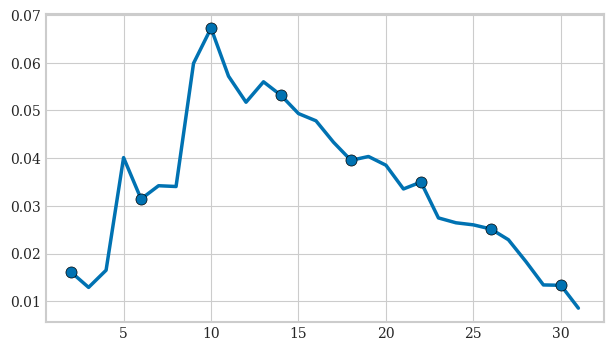

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# 系统论文风格的全局设置
plt.rcParams.update({
    'font.family': 'serif',  # 系统论文常用的字体族
    'pdf.fonttype': 42,      # 确保PDF中字体正确嵌入
    'ps.fonttype': 42,
    'axes.linewidth': 1.5,   # 加粗轴线
    'lines.linewidth': 1.5,  # 加粗曲线
})

def plot_algorithm_performance(data_path, total_gpu=None, bw_type=None, cluster_type=None, if_dynamic=None,
                               if_my=True, if_topo=True, save_path=None):
    # 读取数据
    df = pd.read_csv(data_path)
    
    # 应用指定的筛选条件
    if total_gpu is not None:
        df = df[df['total_gpu'] == total_gpu]
    if if_dynamic is not None:
        df = df[df['if_dynamic'] == if_dynamic]
    
    # 按test_num排序，确保线条正确绘制
    df = df.sort_values(by='test_num')
    
    # 定义要绘制的列和对应的颜色和标记
    # 使用色盲友好的调色板
    algorithms = {
        'BandDisp_time': {'label': 'BandDisp_time', 'color': '#0072B2', 'marker': 'o', 'linestyle': '-', 'include': if_my},
        'Predict_time': {'label': 'Predict_time', 'color': '#F0E442', 'marker': 'P', 'linestyle': '-', 'include': 'predict'},  # 黄色，五边形，实线
        # 'Topo_time': {'label': 'Topo', 'color': '#D55E00', 'marker': 's', 'linestyle': '--', 'include': if_topo},
        # 'UpperBandDisp_time': {'label': 'UpperBandDisp', 'color': '#009E73', 'marker': '^', 'linestyle': '-.', 'include': True},
        # 'Random_time': {'label': 'Random', 'color': '#CC79A7', 'marker': 'D', 'linestyle': ':', 'include': True},
        'Tree_search_time': {'label': 'PTS_time', 'color': '#CC79A7', 'marker': 'D', 'linestyle': ':', 'include': True},
        'EHA_time': {'label': 'EHA_time', 'color': '#56B4E9', 'marker': 'X', 'linestyle': '--', 'include': True},  # 浅蓝色，X形，虚线
    }
    
    # 创建高分辨率的图形，尺寸适合出版要求
    fig, ax = plt.subplots(figsize=(7.2, 4), facecolor='white')
    
    # 绘制每个算法
    for algo, style in algorithms.items():
        if style['include']==True:
            print(f"The mean of the {algo} is : {np.mean(df[algo])}")
            ax.plot(df['test_num'], df[algo], 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
        elif style['include']== 'predict':
            ax.plot(df['test_num'], df[algo]/2, 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
    # 自定义坐标轴
    ax.set_xlabel('Number of Required GPUs', fontweight='bold', fontsize=15)
    ax.set_ylabel('Time (s)', fontweight='bold', fontsize=15)
    
    # 设置x轴仅显示整数值
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 计算y轴范围，添加适当的留白
    y_min = max(0, df[list(a for a, s in algorithms.items() if s['include'])].min().min() * 0.95)
    y_max = df[list(a for a, s in algorithms.items() if s['include'])].max().max() * 1.05
    ax.set_ylim(y_min, y_max)
    
    # 自定义网格 - 更淡且位于数据后面
    ax.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    
    # 增强轴脊
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    
    # 自定义刻度
    ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6, pad=6)
    
    # 计算要显示的图例数量
    included_algorithms_count = sum(1 for algo in algorithms.values() if algo['include'])

    # 将图例放置在图表上方
    legend = ax.legend(
        loc='upper center',          # 定位在顶部中心
        bbox_to_anchor=(0.5, 1.25),  # 调整位置到图表区域之上
        ncol=included_algorithms_count, # 水平排列图例项
        frameon=False,               # 移除边框以获得更简洁的外观
        fontsize=13,                 # 增大图例字体
        handletextpad=0.5,
        borderpad=0.8,  
        handlelength=2.0,
        columnspacing=1.0,
    )
    
    # 添加带有增强样式的图例
    # legend = ax.legend(
    #     frameon=True, 
    #     loc='best', 
    #     fontsize=13,          # 增大图例字体
    #     edgecolor='black',
    #     fancybox=False,
    #     borderpad=0.8,
    #     handletextpad=0.5,
    #     handlelength=2.0,
    #     columnspacing=1.0
    # )
    legend.get_frame().set_linewidth(1.0)
    legend.get_frame().set_alpha(0.9)
    
    # 添加微妙的边框，营造学术感
    for spine in ax.spines.values():
        spine.set_zorder(10)
    
    # 紧凑布局优化间距
    plt.tight_layout(pad=1.2)
    
    # 如果提供路径，保存图形
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', format='pdf')
        print(f"Chart saved to {save_path}")
    
    plt.show()

# 示例用法
plot_algorithm_performance('./Data/Evaluation/H100_Real/H100_26H100_27H100_28H100_29/Part_mean_20_bw_32dim_dynamicTrue.csv',
                           total_gpu=32, 
                           bw_type="Random", 
                           cluster_type="H100_Real", 
                           if_dynamic=True,
                           if_my=True, 
                           if_topo=True, 
                           save_path="./Figures/Evaluation/Time_overhead.pdf")

The mean of the BandDisp_time is : 17.0981739721601
Chart saved to Figures/Evaluation/test.pdf


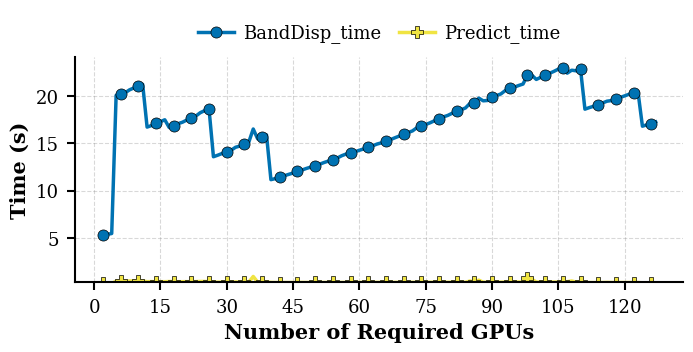

In [17]:
#大规模实验的overhead
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# 系统论文风格的全局设置
plt.rcParams.update({
    'font.family': 'serif',  # 系统论文常用的字体族
    'pdf.fonttype': 42,      # 确保PDF中字体正确嵌入
    'ps.fonttype': 42,
    'axes.linewidth': 1.5,   # 加粗轴线
    'lines.linewidth': 1.5,  # 加粗曲线
})

def plot_algorithm_performance(data_path, total_gpu=None, bw_type=None, cluster_type=None, if_dynamic=None,
                               if_my=True, if_topo=True, save_path=None):
    # 读取数据
    df = pd.read_csv(data_path)
    
    # 应用指定的筛选条件
    if total_gpu is not None:
        df = df[df['total_gpu'] == total_gpu]
    if if_dynamic is not None:
        df = df[df['if_dynamic'] == if_dynamic]
    
    # 按test_num排序，确保线条正确绘制
    df = df.sort_values(by='test_num')
    
    # 定义要绘制的列和对应的颜色和标记
    # 使用色盲友好的调色板
    algorithms = {
        'BandDisp_time': {'label': 'BandDisp_time', 'color': '#0072B2', 'marker': 'o', 'linestyle': '-', 'include': if_my},
        'Predict_time': {'label': 'Predict_time', 'color': '#F0E442', 'marker': 'P', 'linestyle': '-', 'include': 'predict'},  # 黄色，五边形，实线
        # 'Topo_time': {'label': 'Topo', 'color': '#D55E00', 'marker': 's', 'linestyle': '--', 'include': if_topo},
        # 'UpperBandDisp_time': {'label': 'UpperBandDisp', 'color': '#009E73', 'marker': '^', 'linestyle': '-.', 'include': True},
        # 'Random_time': {'label': 'Random', 'color': '#CC79A7', 'marker': 'D', 'linestyle': ':', 'include': True},
        # 'Tree_search_time': {'label': 'PTS_time', 'color': '#CC79A7', 'marker': 'D', 'linestyle': ':', 'include': True},
        # 'EHA_time': {'label': 'EHA_time', 'color': '#56B4E9', 'marker': 'X', 'linestyle': '--', 'include': True},  # 浅蓝色，X形，虚线
    }
    
    # 创建高分辨率的图形，尺寸适合出版要求
    fig, ax = plt.subplots(figsize=(7.2, 4), facecolor='white')
    
    # 绘制每个算法
    for algo, style in algorithms.items():
        if style['include']==True:
            print(f"The mean of the {algo} is : {np.mean(df[algo])}")
            ax.plot(df['test_num'], df[algo], 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
        elif style['include']== 'predict':
            ax.plot(df['test_num'], df[algo]/2, 
                    label=style['label'], 
                    color=style['color'], 
                    marker=style['marker'], 
                    linestyle=style['linestyle'],
                    markersize=8,           # 增大标记尺寸 
                    linewidth=2.5,          # 增大线宽
                    markeredgecolor='black',
                    markeredgewidth=0.5,
                    markevery=4,
                    zorder=3)  # 确保线条在网格之上
    # 自定义坐标轴
    ax.set_xlabel('Number of Required GPUs', fontweight='bold', fontsize=15)
    ax.set_ylabel('Time (s)', fontweight='bold', fontsize=15)
    
    # 设置x轴仅显示整数值
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 计算y轴范围，添加适当的留白
    y_min = max(0, df[list(a for a, s in algorithms.items() if s['include'])].min().min() * 0.95)
    y_max = df[list(a for a, s in algorithms.items() if s['include'])].max().max() * 1.05
    ax.set_ylim(y_min, y_max)
    
    # 自定义网格 - 更淡且位于数据后面
    ax.grid(True, linestyle='--', alpha=0.3, color='gray', zorder=0)
    
    # 增强轴脊
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    
    # 自定义刻度
    ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6, pad=6)
    
    # 计算要显示的图例数量
    included_algorithms_count = sum(1 for algo in algorithms.values() if algo['include'])

    # 将图例放置在图表上方
    legend = ax.legend(
        loc='upper center',          # 定位在顶部中心
        bbox_to_anchor=(0.5, 1.25),  # 调整位置到图表区域之上
        ncol=included_algorithms_count, # 水平排列图例项
        frameon=False,               # 移除边框以获得更简洁的外观
        fontsize=13,                 # 增大图例字体
        handletextpad=0.5,
        borderpad=0.8,  
        handlelength=2.0,
        columnspacing=1.0,
    )
    
    # 添加带有增强样式的图例
    # legend = ax.legend(
    #     frameon=True, 
    #     loc='best', 
    #     fontsize=13,          # 增大图例字体
    #     edgecolor='black',
    #     fancybox=False,
    #     borderpad=0.8,
    #     handletextpad=0.5,
    #     handlelength=2.0,
    #     columnspacing=1.0
    # )
    legend.get_frame().set_linewidth(1.0)
    legend.get_frame().set_alpha(0.9)
    
    # 添加微妙的边框，营造学术感
    for spine in ax.spines.values():
        spine.set_zorder(10)
    
    # 紧凑布局优化间距
    plt.tight_layout(pad=1.2)
    
    # 如果提供路径，保存图形
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', format='pdf')
        print(f"Chart saved to {save_path}")
    
    plt.show()

# 示例用法
plot_algorithm_performance('./Data/Evaluation/4090V100A6000A800H100/myalgo_Part_mean_128_256_dynamicTrue_1000Data.csv',
                           total_gpu=640, 
                           bw_type="Random", 
                           cluster_type="4090V100A6000A800", 
                           if_dynamic=True,
                           if_my=True, 
                           if_topo=True, 
                           save_path="Figures/Evaluation/test.pdf")

# 文章展示图

In [ ]:
from Auto_experiment_H100 import prepare_model_inputs,predict_with_model,BandwidthPredictor,get_gpu_dict_files,load_gpu_bw_dict,ensure_directory_exists
import numpy as np
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = BandwidthPredictor(input_dim=1, hidden_dim=32, num_layers=6, num_heads=8)
best_model.load_state_dict(torch.load('./model/H100_Real/Group_best_bandwidth_predictor_20_bw_32dim.pth'))
best_model.to(device)
best_model.eval()  # 切换到评估模式
for cluster_type in ["H100_26H100_27H100_28H100_29"]: #设置集群复杂度 "V100A6000A800","V100","A6000","A800","4090","4090V100A6000","4090V100A6000A800"
    ensure_directory_exists("./Data/Evaluation/H100_Real", cluster_type)# ./data/utilization #存放数据的地方
    gpu_bw_dict_list = []
    file_list = get_gpu_dict_files(cluster_type, 8)  
    print(file_list)
    for file_name in file_list:
        gpu_bw_dict_list.append(load_gpu_bw_dict(f'./Data/Bandwidth/{file_name}')) #存放单机带宽信息的地方


/tmp/ipykernel_3557014/3803198933.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('./model/H100_Real/Group_best_bandwidth_predictor

目录已存在: ./Data/Evaluation/H100_Real/H100_26H100_27H100_28H100_29
['H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl', 'H100_26_gpu_bw_dict.pkl', 'H100_27_gpu_bw_dict.pkl', 'H100_28_gpu_bw_dict.pkl', 'H100_29_gpu_bw_dict.pkl']
开始预处理带宽数据文件: ./Data/H100_Real/Pune_H100_16M_binary.csv...
带宽数据预处理完成，耗时 

array([228.18])

In [8]:
part_bws_list, node_counts_list, total_counts_list = prepare_model_inputs(
    [np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])], 32, gpu_bw_dict_list, 20
)
# 使用 predict_with_model 获取分数，替代直接模型调用
scores = predict_with_model(best_model, part_bws_list, node_counts_list, total_counts_list, device)
scores

array([226.72])

成功加载 'SimHei' 字体用于显示中文。


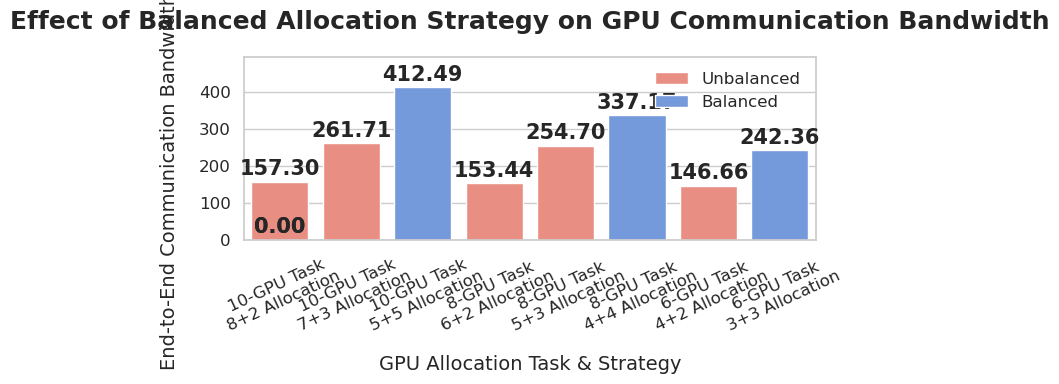

图表已成功保存为 'Figures/Intro/bandwidth_comparison_chart.png'


In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# --- 1. 数据准备 ---
# 创建一个DataFrame来存储绘图所需的数据。
# 这种格式非常适合用seaborn进行分类绘图。
data = {
    'Task': [
        '10-GPU Task', '10-GPU Task','10-GPU Task',
        '8-GPU Task', '8-GPU Task','8-GPU Task',
        '6-GPU Task', '6-GPU Task'
    ],
    'Type': [
        'Unbalanced','Unbalanced', 'Balanced',
        'Unbalanced', 'Unbalanced','Balanced',
        'Unbalanced', 'Balanced'
    ],
    'Strategy': [
        '8+2 Allocation','7+3 Allocation','5+5 Allocation',
        '6+2 Allocation','5+3 Allocation','4+4 Allocation', 
        '4+2 Allocation', '3+3 Allocation'
    ],
    'Bandwidth (GB/s)': [
        157.30,261.71,412.49,
        153.44, 254.70,337.17, 
        146.66, 242.36]
}
df = pd.DataFrame(data)

# 创建一个用于x轴标签的组合列，让标签更清晰
df['X Label'] = df['Task'] + '\n' + df['Strategy']

# --- 2. 字体与风格设置 ---
# 为了正确显示中文和负号，进行字体设置。
# 尝试加载 'SimHei' 字体，如果失败则使用系统默认字体。
try:
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    print("成功加载 'SimHei' 字体用于显示中文。")
except Exception as e:
    print(f"未能加载 'SimHei' 字体，中文可能无法正确显示。错误: {e}")
    print("将使用系统默认字体。")

# 设置图表的美学风格为白色网格背景
sns.set_theme(style="whitegrid")

# --- 3. 图表绘制 ---
# 创建一个画布和子图，并设置图表大小
plt.figure(figsize=(7.2, 4 ))

# 使用seaborn的barplot函数绘制柱状图
# x: x轴数据
# y: y轴数据
# hue: 用于颜色区分的类别
# palette: 调色板，为不同类别指定颜色
# dodge: 由于每个x标签只对应一种策略，所以设为False，柱子不会错开
ax = sns.barplot(
    data=df,
    x='X Label',
    y='Bandwidth (GB/s)',
    hue='Type',
    palette={'Balanced': 'cornflowerblue', 'Unbalanced': 'salmon'},
    dodge=False
)

# --- 4. 图表美化与定制 ---
# 在每个柱子的顶端添加精确的数值标签，使其更易读
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}', # 格式化数字，保留两位小数
        (p.get_x() + p.get_width() / 2., p.get_height()), # 确定标签位置
        ha='center',        # 水平居中
        va='center',        # 垂直居中
        xytext=(0, 9),      # 在柱顶上方9个点的偏移量
        textcoords='offset points',
        fontsize=15,
        fontweight='bold'
    )

# 设置图表标题和坐标轴标签，并增加字体大小和间距
plt.title('Effect of Balanced Allocation Strategy on GPU Communication Bandwidth', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('GPU Allocation Task & Strategy', fontsize=14, labelpad=15)
plt.ylabel('End-to-End Communication Bandwidth (GB/s)', fontsize=14, labelpad=15)

# 调整坐标轴刻度的字体大小
plt.xticks(fontsize=12, rotation=25) # x轴标签不旋转
plt.yticks(fontsize=12)

# 设置Y轴的范围，确保顶部的数值标签有足够的显示空间
ax.set_ylim(0, df['Bandwidth (GB/s)'].max() * 1.2)

# 获取并修改图例，使其更清晰
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    # title='Type',
    fontsize=12,
    title_fontsize=13,
    loc='upper right' # 将图例放在左上角，避免遮挡数据
)

# 自动调整整体布局，防止标签等元素重叠
plt.tight_layout()

# --- 5. 保存并显示图表 ---
# 将生成的图表保存为高分辨率的PNG文件，方便插入论文
output_filename = 'Figures/Intro/bandwidth_comparison_chart.png'
plt.savefig(output_filename, dpi=300)

# 显示图表（在Jupyter Notebook等环境中会自动显示）
plt.show()

print(f"图表已成功保存为 '{output_filename}'")
